# EDA-PREPROCESO-MODELACIONES TFM

In [1]:
# libraries
import pandas as pd
import numpy as np
import functools as ft
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
# modelacion
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
import lightgbm as lgb
# encoding
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler

# seleccion de modelos
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2, mutual_info_classif,
    RFE, SelectFromModel, VarianceThreshold
)

#otros
import time
import warnings
from sklearn.tree import plot_tree
import shap

warnings.filterwarnings('ignore')

## Carga de datos

In [2]:
dt_librosa = pd.read_csv("/home/estebanm/Escritorio/docs_tfm/proyecto_tfm/data/silver/data_aumentada_castellano.csv") 

dt_librosa.head()

,Unnamed: 0,dementia,label,gender,age,total_words,total_sentences,sentence_length_mean,sentence_length_std,type_token_ratio,...,pause_duration_mean,pause_time_ratio,speech_segment_duration_mean,speech_segment_duration_cv,pause_duration_skewness,pause_duration_kurtosis,voiced_ratio,mmse_df_info,schooling_years,articulation_rate_wpm
0,0,2,ad,M,57.0,71.0,4.0,17.750000,14.872374,0.690141,...,0.329075,0.250182,0.867556,0.703391,2.069982,4.332522,0.708787,13.0,17.0,64.482952
1,1,2,ad,M,65.0,70.0,3.0,23.333333,3.399346,0.685714,...,0.344533,0.250000,0.612211,0.645111,1.558600,1.956037,0.562693,28.0,NaN,135.489676
2,2,2,ad,M,67.0,77.0,4.0,19.250000,8.842370,0.714286,...,0.384000,0.250217,0.892690,0.718931,3.689300,15.348264,0.702867,23.0,17.0,167.357083
3,3,2,ad,M,69.0,68.0,1.0,68.000000,0.000000,0.705882,...,0.337778,0.250219,2.122000,1.420813,0.457952,-0.760515,0.931519,28.0,12.0,149.300752
4,4,2,ad,M,72.0,66.0,3.0,22.000000,13.140269,0.742424,...,0.468571,0.250203,0.578000,0.515021,1.403975,1.385860,0.705452,19.0,8.0,67.159085


In [3]:
dt_librosa[['dementia', 'label']].value_counts()


dementia  label
0         hc       1459
1         mci       523
2         ad        362
0         mci         5
1         hc          4
2         mci         3
0         ad          1
Name: count, dtype: int64

In [4]:
dt_librosa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2357 entries, 0 to 2356
Data columns (total 51 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    2357 non-null   int64  
 1   dementia                      2357 non-null   int64  
 2   label                         2357 non-null   object 
 3   gender                        2357 non-null   object 
 4   age                           2357 non-null   float64
 5   total_words                   2357 non-null   float64
 6   total_sentences               2357 non-null   float64
 7   sentence_length_mean          2357 non-null   float64
 8   sentence_length_std           2357 non-null   float64
 9   type_token_ratio              2357 non-null   float64
 10  mattr_50                      2357 non-null   float64
 11  noun_ratio                    2357 non-null   float64
 12  content_verb_ratio            2357 non-null   float64
 13  adj

In [5]:
dt_librosa.gender

0       M
1       M
2       M
3       M
4       M
       ..
2352    M
2353    W
2354    W
2355    W
2356    M
Name: gender, Length: 2357, dtype: object

In [6]:
dt_librosa.describe()

,Unnamed: 0,dementia,age,total_words,total_sentences,sentence_length_mean,sentence_length_std,type_token_ratio,mattr_50,noun_ratio,...,pause_duration_mean,pause_time_ratio,speech_segment_duration_mean,speech_segment_duration_cv,pause_duration_skewness,pause_duration_kurtosis,voiced_ratio,mmse_df_info,schooling_years,articulation_rate_wpm
count,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,...,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2355.000000,2342.000000,2357.000000
mean,1178.000000,0.533305,76.860485,69.311105,3.277453,33.464285,5.150867,0.702931,0.744476,0.300569,...,0.336303,0.250088,0.849151,0.700635,1.573770,3.175807,0.719023,25.997863,9.090407,133.154173
std,680.551615,0.747558,7.533849,6.817322,2.390828,21.531436,4.813878,0.033201,0.031346,0.039270,...,0.089970,0.000199,0.366809,0.129569,0.739086,3.886438,0.128968,4.089008,3.294647,38.579887
min,0.000000,0.000000,50.000000,43.000000,0.914264,3.266667,-0.171225,0.450000,0.560000,0.137255,...,0.134261,0.249589,0.325053,0.386939,-0.378134,-1.465031,0.120301,9.000000,-0.004906,31.208930
25%,589.000000,0.000000,71.000445,66.000000,1.788882,16.200000,0.498097,0.694219,0.733171,0.272727,...,0.271444,0.249970,0.613476,0.607869,1.105490,0.677622,0.667853,24.000000,7.363995,106.449872
50%,1178.000000,0.000000,77.654854,67.083747,2.617194,28.349131,5.240948,0.711764,0.751236,0.304348,...,0.337607,0.250065,0.751404,0.687857,1.475772,2.016621,0.741172,27.478113,8.005982,134.271590
75%,1767.000000,1.000000,82.343863,70.000000,4.555989,44.198288,7.348469,0.720304,0.760250,0.330977,...,0.396885,0.250239,0.957296,0.776520,1.945598,4.260383,0.805806,28.971333,11.210603,161.310748
max,2356.000000,2.000000,96.000000,144.000000,30.000000,95.000000,27.500000,0.776119,0.819091,0.385714,...,0.657000,0.250597,4.214857,1.424362,4.894557,26.052424,0.967681,32.000000,19.000000,279.921686


In [7]:
dt_librosa.dementia.value_counts(normalize=True)

dementia
0    0.621553
1    0.223589
2    0.154858
Name: proportion, dtype: float64

In [8]:
dt_librosa['dementia'] = dt_librosa['dementia'].replace(2, 1)

In [9]:
dt_librosa.dementia.value_counts(normalize=True)

dementia
0    0.621553
1    0.378447
Name: proportion, dtype: float64

In [10]:
# reemplazar valores negativos por cero
num_col = dt_librosa.select_dtypes(['int64', 'float64']).columns
dt_librosa[num_col] = dt_librosa[num_col].clip(lower=0)

## Preprocesamiento

### Valores perdidos-imputaciones

In [11]:
dt_librosa.isnull().sum()

Unnamed: 0                       0
dementia                         0
label                            0
gender                           0
age                              0
total_words                      0
total_sentences                  0
sentence_length_mean             0
sentence_length_std              0
type_token_ratio                 0
mattr_50                         0
noun_ratio                       0
content_verb_ratio               0
adj_adv_ratio                    0
function_word_ratio              0
subordinate_sentence_ratio       0
lexical_repetitions              0
reformulations                   0
fillers                          0
idea_density                     0
local_coherence_bigram          90
lexical_error_rate               0
pronoun_to_propn_ratio           0
mean_word_length                 0
readability                      0
incomplete_sentence_ratio        0
speech_rate_wpm                  0
f0_mean                          0
f0_std              

In [12]:
dt_librosa.gender.value_counts()

gender
W    1692
M     665
Name: count, dtype: int64

In [13]:
dt_librosa.schooling_years.value_counts()

schooling_years
8.000000     148
12.000000     63
6.000000      54
17.000000     32
3.000000      19
            ... 
6.769518       1
8.002605       1
8.059822       1
6.918262       1
12.079612      1
Name: count, Length: 2013, dtype: int64

In [14]:
dt_librosa.age.value_counts()

age
82.000000    23
80.000000    21
81.000000    21
67.000000    20
76.000000    18
             ..
65.152611     1
83.066679     1
79.048998     1
80.673969     1
80.252691     1
Name: count, Length: 2043, dtype: int64

In [15]:
# porcentaje de valores perdidos 
dt_librosa['gender'].isnull().sum()/len(dt_librosa) * 100

np.float64(0.0)

In [16]:
# imputaciones con mediana
def imputation_nas(df, var):
    """ Imputaciones con la mediana """
    df[var] = df[var].fillna(df[var].median())
    return df[var]



In [17]:
imputation_nas(dt_librosa, 'local_coherence_bigram')

0       0.000000
1       0.000000
2       0.000000
3       0.000067
4       0.000000
          ...   
2352    0.000000
2353    0.000000
2354    0.000100
2355    0.016532
2356    0.000057
Name: local_coherence_bigram, Length: 2357, dtype: float64

In [18]:
imputation_nas(dt_librosa, 'schooling_years')

0       17.000000
1        8.005982
2       17.000000
3       12.000000
4        8.000000
          ...    
2352    11.909458
2353     6.011416
2354    16.993945
2355     8.015323
2356    16.237475
Name: schooling_years, Length: 2357, dtype: float64

In [19]:
imputation_nas(dt_librosa, 'mmse_df_info')

0       13.000000
1       28.000000
2       23.000000
3       28.000000
4       19.000000
          ...    
2352    29.939767
2353    22.560554
2354    24.425479
2355    27.427152
2356    22.950260
Name: mmse_df_info, Length: 2357, dtype: float64

In [20]:
# Identificar columnas categóricas
cat_cols = dt_librosa.select_dtypes(include=['object', 'category']).columns.tolist()
# calcular la moda para cada columna categorica
modas = {}
for col in cat_cols:
    moda = dt_librosa[col].mode()
    if not moda.empty:
        modas[col] = moda[0]
        print(f"{col}: Moda = '{modas[col]}' ({dt_librosa[col].isna().sum()} nulos a reemplazar)")
    else:
        modas[col] = None
        print(f"{col}: No hay moda, todos los valores son NAN's")

# imputar valores nulos
dt_librosa = dt_librosa.copy()
for col, moda_valor in modas.items():
    if moda_valor is not None:
        # contal nulos antes y despues
        nulos_antes = dt_librosa[col].isna().sum()
        dt_librosa[col] = dt_librosa[col].fillna(moda_valor)
        nulos_despues = dt_librosa[col].isna().sum()

        print(f"{col}: {nulos_antes}→ {nulos_despues} nulos ")

label: Moda = 'hc' (0 nulos a reemplazar)
gender: Moda = 'W' (0 nulos a reemplazar)
label: 0→ 0 nulos 
gender: 0→ 0 nulos 


In [21]:
dt_librosa.isnull().sum()

Unnamed: 0                      0
dementia                        0
label                           0
gender                          0
age                             0
total_words                     0
total_sentences                 0
sentence_length_mean            0
sentence_length_std             0
type_token_ratio                0
mattr_50                        0
noun_ratio                      0
content_verb_ratio              0
adj_adv_ratio                   0
function_word_ratio             0
subordinate_sentence_ratio      0
lexical_repetitions             0
reformulations                  0
fillers                         0
idea_density                    0
local_coherence_bigram          0
lexical_error_rate              0
pronoun_to_propn_ratio          0
mean_word_length                0
readability                     0
incomplete_sentence_ratio       0
speech_rate_wpm                 0
f0_mean                         0
f0_std                          0
f0_range      

In [22]:
dt_librosa.columns

Index(['Unnamed: 0', 'dementia', 'label', 'gender', 'age', 'total_words',
       'total_sentences', 'sentence_length_mean', 'sentence_length_std',
       'type_token_ratio', 'mattr_50', 'noun_ratio', 'content_verb_ratio',
       'adj_adv_ratio', 'function_word_ratio', 'subordinate_sentence_ratio',
       'lexical_repetitions', 'reformulations', 'fillers', 'idea_density',
       'local_coherence_bigram', 'lexical_error_rate',
       'pronoun_to_propn_ratio', 'mean_word_length', 'readability',
       'incomplete_sentence_ratio', 'speech_rate_wpm', 'f0_mean', 'f0_std',
       'f0_range', 'loudness_mean', 'loudness_std', 'jitter_local',
       'shimmer_local', 'hnr', 'alpha_ratio', 'hammarberg_index',
       'spectral_slope_mean', 'spectral_slope_std', 'duracion_s',
       'pause_count', 'pause_duration_mean', 'pause_time_ratio',
       'speech_segment_duration_mean', 'speech_segment_duration_cv',
       'pause_duration_skewness', 'pause_duration_kurtosis', 'voiced_ratio',
       'mmse_df_

In [23]:
# eliminar algunas variables que no son utiles para el modelo
dt_lib = dt_librosa.drop(['Unnamed: 0', 'label'], axis=1) # 'sujeto', 'audio_file', 

In [24]:
# eliminar los valores perdidos
dt_lib= dt_lib.dropna()

In [25]:
# dimensiones datos
dt_lib.shape

(2357, 49)

In [26]:
# revisar variable dependiente
dt_lib.dementia.value_counts(normalize=True)

dementia
0    0.621553
1    0.378447
Name: proportion, dtype: float64

### Transformaciones 

In [27]:
# genero
dt_lib.gender.value_counts()

gender
W    1692
M     665
Name: count, dtype: int64

In [28]:
# gender
encoded_df = pd.get_dummies(dt_lib[['gender']], prefix='gender', drop_first=True)
dt_lib = pd.concat([dt_lib, encoded_df], axis=1)


In [29]:
dt_lib = dt_lib.drop(['gender'], axis=1)


In [30]:
# schooling_years
dt_lib['schooling_years'] = pd.cut(
    dt_lib['schooling_years'],
    bins=[0, 6, 8.5, 11, 19],
    labels=['basica', 'media', 'tecnica', 'universitaria'],
    include_lowest=True
)

In [31]:
encoded_df = pd.get_dummies(dt_lib[['schooling_years']], prefix='schooling_years', drop_first=True)
dt_lib = pd.concat([dt_lib, encoded_df], axis=1)

In [32]:
dt_lib = dt_lib.drop(['schooling_years'], axis=1)

In [33]:
# age
dt_lib['age'] = pd.cut(
    dt_lib['age'],
    bins=[50, 71, 77, 82, 96],
    labels=['adulto_q25', 'adulto_mediano', 'adulto_q75', 'adulto_max'],
    include_lowest=True
)

In [34]:
encoded_df = pd.get_dummies(dt_lib[['age']], prefix='age', drop_first=True)
dt_lib = pd.concat([dt_lib, encoded_df], axis=1)

In [35]:
dt_lib = dt_lib.drop(['age'], axis=1)
dt_lib.head()

,dementia,total_words,total_sentences,sentence_length_mean,sentence_length_std,type_token_ratio,mattr_50,noun_ratio,content_verb_ratio,adj_adv_ratio,...,voiced_ratio,mmse_df_info,articulation_rate_wpm,gender_W,schooling_years_media,schooling_years_tecnica,schooling_years_universitaria,age_adulto_mediano,age_adulto_q75,age_adulto_max
0,1,71.0,4.0,17.750000,14.872374,0.690141,0.714545,0.281690,0.126761,0.042254,...,0.708787,13.0,64.482952,False,False,False,True,False,False,False
1,1,70.0,3.0,23.333333,3.399346,0.685714,0.714286,0.300000,0.071429,0.085714,...,0.562693,28.0,135.489676,False,True,False,False,False,False,False
2,1,77.0,4.0,19.250000,8.842370,0.714286,0.755000,0.272727,0.064935,0.116883,...,0.702867,23.0,167.357083,False,False,False,True,False,False,False
3,1,68.0,1.0,68.000000,0.000000,0.705882,0.727368,0.308824,0.058824,0.117647,...,0.931519,28.0,149.300752,False,False,False,True,False,False,False
4,1,66.0,3.0,22.000000,13.140269,0.742424,0.794118,0.242424,0.060606,0.090909,...,0.705452,19.0,67.159085,False,True,False,False,True,False,False


In [36]:
# eliminar los valores perdidos
dt_lib = dt_lib.dropna()

In [37]:
# revisiones del dataset
dt_lib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2357 entries, 0 to 2356
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   dementia                       2357 non-null   int64  
 1   total_words                    2357 non-null   float64
 2   total_sentences                2357 non-null   float64
 3   sentence_length_mean           2357 non-null   float64
 4   sentence_length_std            2357 non-null   float64
 5   type_token_ratio               2357 non-null   float64
 6   mattr_50                       2357 non-null   float64
 7   noun_ratio                     2357 non-null   float64
 8   content_verb_ratio             2357 non-null   float64
 9   adj_adv_ratio                  2357 non-null   float64
 10  function_word_ratio            2357 non-null   float64
 11  subordinate_sentence_ratio     2357 non-null   float64
 12  lexical_repetitions            2357 non-null   f

### Normalizacion

In [38]:
# Min-Max
scaler_minmax = MinMaxScaler()
num_cols = dt_lib.iloc[:, 1:].select_dtypes(include=['int64', 'float64']).columns
dt_lib[num_cols] = scaler_minmax.fit_transform(dt_lib[num_cols])
dt_lib.describe()

,dementia,total_words,total_sentences,sentence_length_mean,sentence_length_std,type_token_ratio,mattr_50,noun_ratio,content_verb_ratio,adj_adv_ratio,...,pause_count,pause_duration_mean,pause_time_ratio,speech_segment_duration_mean,speech_segment_duration_cv,pause_duration_skewness,pause_duration_kurtosis,voiced_ratio,mmse_df_info,articulation_rate_wpm
count,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,...,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000,2357.000000
mean,0.378447,0.260506,0.081249,0.329189,0.187448,0.775577,0.712012,0.657307,0.329373,0.438067,...,0.079789,0.386507,0.494911,0.134737,0.302380,0.321627,0.124563,0.706557,0.739092,0.409891
std,0.485103,0.067498,0.082199,0.234718,0.174894,0.101806,0.120986,0.158053,0.106056,0.153735,...,0.076004,0.172113,0.197097,0.094300,0.124895,0.150791,0.146689,0.152196,0.177717,0.155118
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.227723,0.030070,0.140988,0.018113,0.748863,0.668380,0.545250,0.239581,0.367865,...,0.047473,0.262431,0.378030,0.074149,0.212960,0.225861,0.026010,0.646171,0.652174,0.302521
50%,0.000000,0.238453,0.058549,0.273428,0.190580,0.802662,0.738104,0.672516,0.323404,0.423017,...,0.064932,0.389001,0.472470,0.109607,0.290062,0.301513,0.077406,0.732695,0.803396,0.414384
75%,1.000000,0.267327,0.125207,0.446202,0.267217,0.828851,0.772894,0.779691,0.378026,0.519116,...,0.086637,0.502401,0.645070,0.162539,0.375528,0.397502,0.163531,0.808970,0.868278,0.523101
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Modelos

In [39]:
#  Separar las variables X & y
X = dt_lib.drop('dementia', axis=1)
y = dt_lib['dementia']

print(f"\nX shape:{X.shape}")
print(f"\ny shape:{y.shape}")
print(f"n Distribucion de clases:")
print(y.value_counts(normalize=True))


X shape:(2357, 52)

y shape:(2357,)
n Distribucion de clases:
dementia
0    0.621553
1    0.378447
Name: proportion, dtype: float64


In [40]:
# split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=10, stratify=y)
print(f'Train set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nChurn en train: {y_train.mean()*100:.1f}%')
print(f'Churn en test: {y_test.mean()*100:.1f}%')

Train set: (1649, 52)
Test set: (708, 52)

Churn en train: 37.8%
Churn en test: 37.9%


## Seleccion de caracteristicas

In [41]:
# SelectKBest con Anova F-test

k_best = 30
selector_kbest = SelectKBest(score_func=f_classif, k=k_best)
X_train_kbest = selector_kbest.fit_transform(X_train, y_train)
X_test_kbest = selector_kbest.transform(X_test)

print('FILTER METHOD: SelectKBest (ANOVA F-test)')
print('='*60)
print(f'K (features seleccionadas): {k_best}')
print(f'Features originales: {X_train.shape[1]}')
print(f'Features seleccionadas: {X_train_kbest.shape[1]}')

# obtener los scores
feature_scores = pd.DataFrame({
    'feature': X_train.columns,
    'score': selector_kbest.scores_
}).sort_values('score', ascending=False)

print(f"\nTop {k_best} features por score F:")
print(feature_scores.head(k_best))

# Entrenar el modelo
model_kbest = RandomForestClassifier(n_estimators=100, random_state=42)
model_kbest.fit(X_train_kbest, y_train)
y_pred_kbest = model_kbest.predict(X_test_kbest)
accuracy_kbest = accuracy_score(y_test, y_pred_kbest)
print(f"\nAccuracy con selectKBest: {accuracy_kbest:.4f}")

FILTER METHOD: SelectKBest (ANOVA F-test)
K (features seleccionadas): 30
Features originales: 52
Features seleccionadas: 30

Top 30 features por score F:
                          feature       score
43                   mmse_df_info  919.624529
21                speech_rate_wpm  232.059636
44          articulation_rate_wpm  230.749187
34                     duracion_s  193.860712
51                 age_adulto_max  101.518375
31               hammarberg_index   65.869189
36            pause_duration_mean   63.303365
25                  loudness_mean   61.241676
35                    pause_count   59.783867
23                         f0_std   59.432900
26                   loudness_std   55.163180
11            lexical_repetitions   52.385319
27                   jitter_local   48.911784
42                   voiced_ratio   42.979445
18               mean_word_length   42.580273
1                 total_sentences   37.210348
16             lexical_error_rate   32.966295
6                 

In [42]:
# Recursive Feature Elimination (RFE)

n_features_rfe = 25
estimator = LogisticRegression(max_iter=1000, random_state=23)
selector_rfe = RFE(estimator, n_features_to_select=n_features_rfe, step=1)
X_train_rfe = selector_rfe.fit_transform(X_train, y_train)
X_test_rfe = selector_rfe.transform(X_test)

print(f"Wrapper Method: Recursive Feature Elimination")
print(f"="*80)
print(f"Features seleccionadas: {n_features_rfe}")

# selecciondo features con su rankings
feature_ranking = pd.DataFrame({
    'feature': X_train.columns,
    'selected': selector_rfe.support_,
    'ranking': selector_rfe.ranking_
}).sort_values('ranking')

print("\nFeatures seleccionadas (ranking=1):")
print(list(feature_ranking[feature_ranking['ranking'] ==1]['feature']))

# entrenar al modelo
model_rfe = RandomForestClassifier(n_estimators=100, random_state=23)
model_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = model_rfe.predict(X_test_rfe)
accuracy_rfe = accuracy_score(y_test, y_pred_rfe)
print(f"\nAccuracy con RFE:{accuracy_rfe:.4f}")

Wrapper Method: Recursive Feature Elimination
Features seleccionadas: 25

Features seleccionadas (ranking=1):
['total_words', 'total_sentences', 'sentence_length_mean', 'type_token_ratio', 'local_coherence_bigram', 'lexical_repetitions', 'subordinate_sentence_ratio', 'function_word_ratio', 'loudness_mean', 'jitter_local', 'hnr', 'shimmer_local', 'incomplete_sentence_ratio', 'speech_rate_wpm', 'f0_std', 'pronoun_to_propn_ratio', 'alpha_ratio', 'hammarberg_index', 'schooling_years_universitaria', 'voiced_ratio', 'mmse_df_info', 'speech_segment_duration_cv', 'pause_duration_mean', 'spectral_slope_mean', 'age_adulto_max']

Accuracy con RFE:0.9350


\Embedded method: Feature importance

Top 20 features mas impornates:
                         feature  importance
43                  mmse_df_info    0.166299
21               speech_rate_wpm    0.050951
44         articulation_rate_wpm    0.038013
34                    duracion_s    0.036823
31              hammarberg_index    0.031288
2           sentence_length_mean    0.027984
27                  jitter_local    0.024988
8                  adj_adv_ratio    0.024755
32           spectral_slope_mean    0.023736
1                total_sentences    0.023560
10    subordinate_sentence_ratio    0.022437
19                   readability    0.022075
42                  voiced_ratio    0.020895
28                 shimmer_local    0.019804
23                        f0_std    0.019680
39    speech_segment_duration_cv    0.018318
18              mean_word_length    0.017808
38  speech_segment_duration_mean    0.017687
22                       f0_mean    0.017528
26                  loudness_s

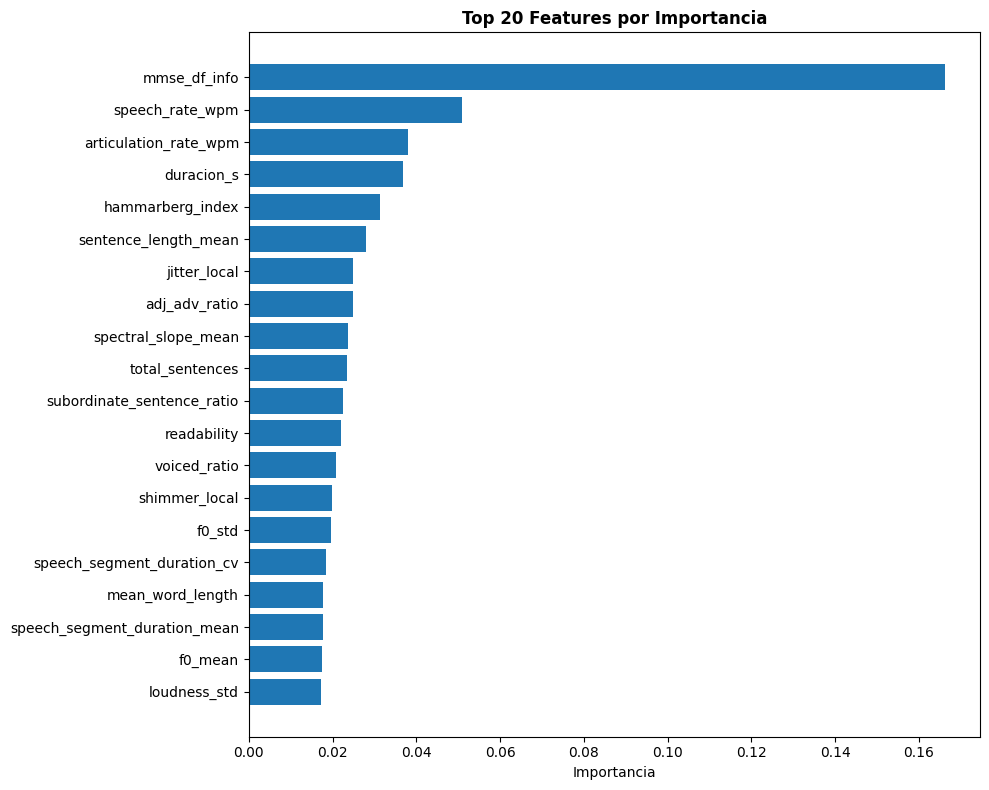

In [43]:
## Feature importance 

rf_importance = RandomForestClassifier(n_estimators=100, random_state=23)
rf_importance.fit(X_train, y_train)

#obtener importancia
importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_importance.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\Embedded method: Feature importance")
print("="*80)
print(f"\nTop 20 features mas impornates:")
print(importances.head(20))

# visualizaciones
plt.figure(figsize=(10,8))
top_n = 20
plt.barh(range(top_n), importances['importance'].head(top_n))
plt.yticks(range(top_n), importances['feature'].head(top_n))
plt.xlabel('Importancia')
plt.title(f"Top {top_n} Features por Importancia", fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Variables elegidas para el proceso de modelos

In [44]:
# Se utiliza un mix de variables de los tres metodos revisados

dt_lib = dt_lib[['total_words', 'mmse_df_info', 'voiced_ratio', 'speech_segment_duration_cv', 
                 'pause_duration_mean', 'spectral_slope_mean', 'hammarberg_index', 'hnr', 'shimmer_local', 
                 'f0_std', 'incomplete_sentence_ratio', 'pronoun_to_propn_ratio', 'loudness_mean', 'age_adulto_max', 
                 'sentence_length_mean', 'total_sentences', 'function_word_ratio', 'subordinate_sentence_ratio', 
                 'type_token_ratio', 'lexical_repetitions', 
                 'schooling_years_universitaria', 'schooling_years_media', 'age_adulto_mediano', 'dementia']] 




In [45]:
dt_lib.shape

(2357, 24)

In [46]:
#  Separar las variables X & y
X = dt_lib.drop('dementia', axis=1)
y = dt_lib['dementia']

print(f"\nX shape:{X.shape}")
print(f"\ny shape:{y.shape}")
print(f"n Distribucion de clases:")
print(y.value_counts(normalize=True))


X shape:(2357, 23)

y shape:(2357,)
n Distribucion de clases:
dementia
0    0.621553
1    0.378447
Name: proportion, dtype: float64


In [47]:
# split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=10, stratify=y)
print(f'Train set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'\nChurn en train: {y_train.mean()*100:.1f}%')
print(f'Churn en test: {y_test.mean()*100:.1f}%')

Train set: (1649, 23)
Test set: (708, 23)

Churn en train: 37.8%
Churn en test: 37.9%


## Modelos

### Regresión Logística

In [48]:
logreg = LogisticRegression(random_state=23)

rejilla_parametros = {'C': np.linspace(0.1, 10, 100), 'penalty':['l2', 'l1']}
grid_lr = GridSearchCV(logreg, rejilla_parametros)
model_lr = grid_lr.fit(X_train, y_train)
model_lr.best_params_

{'C': np.float64(1.1), 'penalty': 'l2'}

In [49]:
grid_logreg_pred = model_lr.best_estimator_.predict(X_test)

accuracy_logreg = accuracy_score(y_test, grid_logreg_pred)
y_prods_logreg = model_lr.predict_proba(X_test)[:,1]

In [50]:
print(f"Accuracy {accuracy_logreg}")

Accuracy 0.8192090395480226


In [51]:
# Matriz confusion
cm_logreg = confusion_matrix(y_test, grid_logreg_pred)
print(f"Matrix de confusion:")
print(cm_logreg)

Matrix de confusion:
[[394  46]
 [ 82 186]]


In [52]:
# Reporte de classificacion
print(f"\nReporte de clasificacion:")
print(classification_report(y_test, grid_logreg_pred))


Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       440
           1       0.80      0.69      0.74       268

    accuracy                           0.82       708
   macro avg       0.81      0.79      0.80       708
weighted avg       0.82      0.82      0.82       708



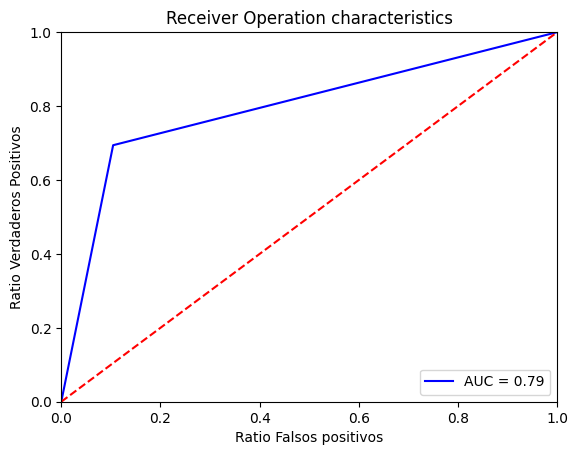

In [53]:
## Area bajo la curva (AUC)
fpr, tpr, threshold = roc_curve(y_test, grid_logreg_pred)
roc_auc = roc_auc_score(y_test, grid_logreg_pred)

# plot

plt.title("Receiver Operation characteristics")
plt.plot(fpr, tpr, 'b', label="AUC = %0.2f" % roc_auc)
plt.legend(loc = "lower right")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel("Ratio Verdaderos Positivos")
plt.xlabel("Ratio Falsos positivos")
plt.show()

### Arboles decisiones

In [54]:
param_grid = {
    'max_depth': [2, 3, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 15, 20],
    'criterion': ['gini', 'entropy']
}

dectree = GridSearchCV(estimator=DecisionTreeClassifier(),
                       param_grid = param_grid, cv=5,
                       scoring='accuracy')

model_tree = dectree.fit(X_train, y_train)

print(f"Best hyperparmeters: {model_tree.best_params_}")
print(f"Best score: {model_tree.best_score_}")

Best hyperparmeters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
Best score: 0.8756820484480059


In [55]:
y_pred_dectree= model_tree.best_estimator_.predict(X_test)
accuracy_dectree = accuracy_score(y_test, y_pred_dectree)
y_prods_dectree = model_tree.predict_proba(X_test)[:,1]

In [56]:
print(f"Accuracy {accuracy_dectree}")

Accuracy 0.8418079096045198


In [57]:
# Matriz confusion
cm_dectree= confusion_matrix(y_test, y_pred_dectree)
print(f"\nMatrix de confusion:")
print(cm_dectree)


Matrix de confusion:
[[377  63]
 [ 49 219]]


In [58]:
# Reporte de classificacion
print(f"\nReporte de clasificacion:")
print(classification_report(y_test, y_pred_dectree))


Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       440
           1       0.78      0.82      0.80       268

    accuracy                           0.84       708
   macro avg       0.83      0.84      0.83       708
weighted avg       0.84      0.84      0.84       708



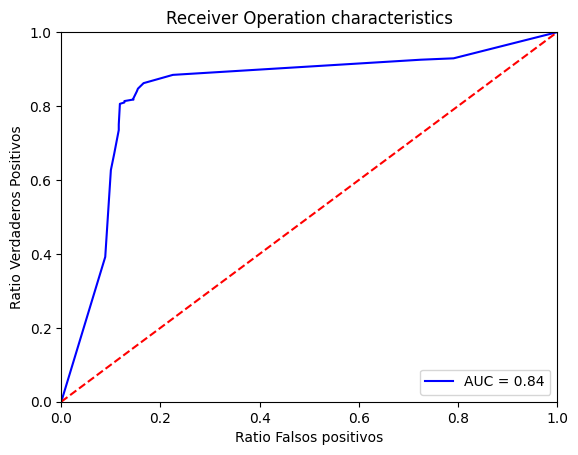

In [59]:
## Area bajo la curva (AUC)
fpr, tpr, threshold = roc_curve(y_test, y_prods_dectree)
roc_auc = roc_auc_score(y_test, y_prods_dectree)

# plot

plt.title("Receiver Operation characteristics")
plt.plot(fpr, tpr, 'b', label="AUC = %0.2f" % roc_auc)
plt.legend(loc = "lower right")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel("Ratio Verdaderos Positivos")
plt.xlabel("Ratio Falsos positivos")
plt.show()

### Random Forest

In [60]:
rf = RandomForestClassifier()
param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': [5, 10, 15, 20, 25, None],
    'max_features': uniform(0.1, 0.9),  # Proporción
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
}

grid_rf= RandomizedSearchCV(
    rf, param_dist, n_iter=100, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42
)
model_grid_rf = grid_rf.fit(X_train, y_train)

print(f'Best hyperparameters are {model_grid_rf.best_params_}')
print(f'Best score is: {model_grid_rf.best_score_}')

Best hyperparameters are {'max_depth': None, 'max_features': np.float64(0.12974565961049356), 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 452}
Best score is: 0.9750823918174666


In [61]:
y_pred_rf = model_grid_rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
y_prods_rf = grid_rf.predict_proba(X_test)[:,1]

In [62]:
print(f"Accuracy {accuracy_rf}")

Accuracy 0.9307909604519774


In [63]:
# Matriz confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"\nMatrix de confusion:")
print(cm_rf)


Matrix de confusion:
[[412  28]
 [ 21 247]]


In [64]:
# Reporte de classificacion
print(f"\nReporte de clasificacion:")
print(classification_report(y_test, y_pred_rf))


Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       440
           1       0.90      0.92      0.91       268

    accuracy                           0.93       708
   macro avg       0.92      0.93      0.93       708
weighted avg       0.93      0.93      0.93       708



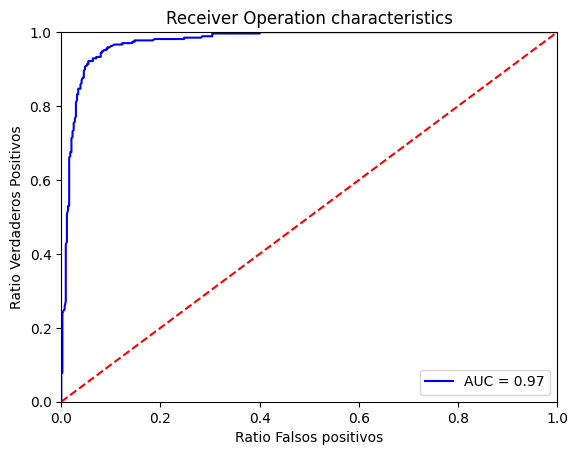

In [65]:
## Area bajo la curva (AUC)
fpr, tpr, threshold = roc_curve(y_test, y_prods_rf)
roc_auc = roc_auc_score(y_test, y_prods_rf)

# plot

plt.title("Receiver Operation characteristics")
plt.plot(fpr, tpr, 'b', label="AUC = %0.2f" % roc_auc)
plt.legend(loc = "lower right")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel("Ratio Verdaderos Positivos")
plt.xlabel("Ratio Falsos positivos")
plt.show()

### XGBoost 

In [66]:
xgb = XGBClassifier()
param_grid = {
    'max_depth': [3, 5, 7, 9, 10, 12],
    'learning_rate': [0.1, 0.01, 0.001],
    'subsample': [0.5, 0.7, 1]
}
grid_xgb = GridSearchCV(xgb, param_grid, cv=3, scoring='accuracy')
model_grid_xgb = grid_xgb.fit(X_train, y_train)

print(f'Best hyperparameters are {model_grid_xgb.best_params_}')
print(f'Best score is: {model_grid_xgb.best_score_}')

Best hyperparameters are {'learning_rate': 0.1, 'max_depth': 7, 'subsample': 0.7}
Best score is: 0.9114555389965225


In [67]:
y_pred_xgb = model_grid_xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
y_prods_xgb = model_grid_xgb.predict_proba(X_test)[:,1]

In [68]:
print(f"Accuracy {accuracy_xgb}")

Accuracy 0.9336158192090396


In [69]:
# Matriz confusion
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f"\nMatrix de confusion:")
print(cm_xgb)


Matrix de confusion:
[[416  24]
 [ 23 245]]


In [70]:
# Reporte de classificacion
print(f"\nReporte de clasificacion:")
print(classification_report(y_test, y_pred_xgb))


Reporte de clasificacion:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       440
           1       0.91      0.91      0.91       268

    accuracy                           0.93       708
   macro avg       0.93      0.93      0.93       708
weighted avg       0.93      0.93      0.93       708



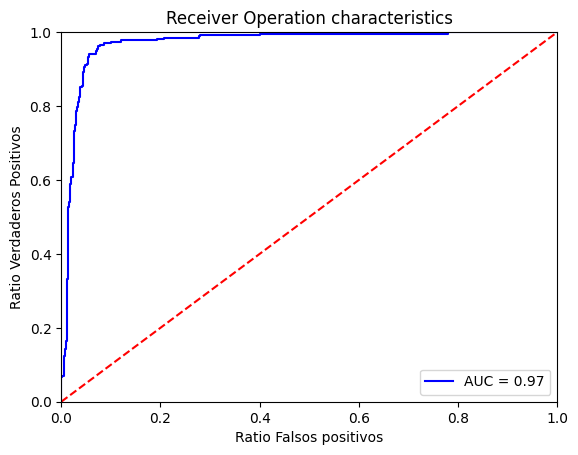

In [71]:
## Area bajo la curva (AUC)
fpr, tpr, threshold = roc_curve(y_test, y_prods_xgb)
roc_auc = roc_auc_score(y_test, y_prods_xgb)

# plot

plt.title("Receiver Operation characteristics")
plt.plot(fpr, tpr, 'b', label="AUC = %0.2f" % roc_auc)
plt.legend(loc = "lower right")
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel("Ratio Verdaderos Positivos")
plt.xlabel("Ratio Falsos positivos")
plt.show()

## Champions model

In [72]:
import joblib
import os

# archivos
resultados = '/home/estebanm/Escritorio/docs_tfm/proyecto_tfm/results'
os.makedirs(resultados, exist_ok=True)

# modelo campeon
modelo = 'ramdom_forest.joblib'
ruta_completa = os.path.join(resultados, modelo)
# guardar el mejor modelo
joblib.dump(model_grid_rf.best_estimator_, ruta_completa)
print(f"Modelo guardado en: {ruta_completa}")


Modelo guardado en: /home/estebanm/Escritorio/docs_tfm/proyecto_tfm/results/ramdom_forest.joblib


### Revisiones de resultados

In [73]:
#!pip install shap

<Figure size 2000x1000 with 0 Axes>

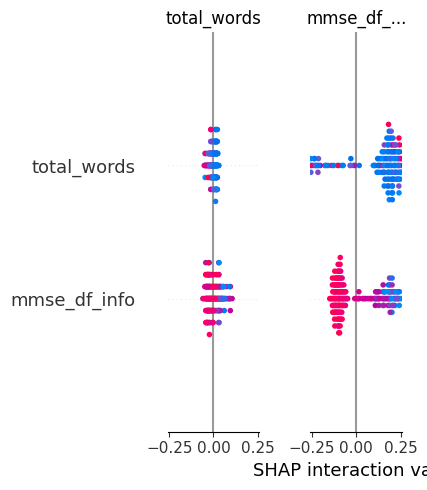

In [74]:
# Mejor modelo
best_rf = model_grid_rf.best_estimator_

# Muestra de 200 instancias
x_sample = X_test.sample(n=200, random_state=42)

# Explicador y valores SHAP
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(x_sample)

# Para la clase positiva (asumiendo que es la segunda, índice 1)
if isinstance(shap_values, list):
    shap_values_class = shap_values[1]  # valores para la clase positiva
else:
    shap_values_class = shap_values


plt.figure(figsize=(20, 10))  
shap.summary_plot(
    shap_values_class, 
    x_sample, 
    plot_type='bar', 
    feature_names=x_sample.columns,
    max_display=5,            
    show=False
)
plt.tight_layout()
plt.show()

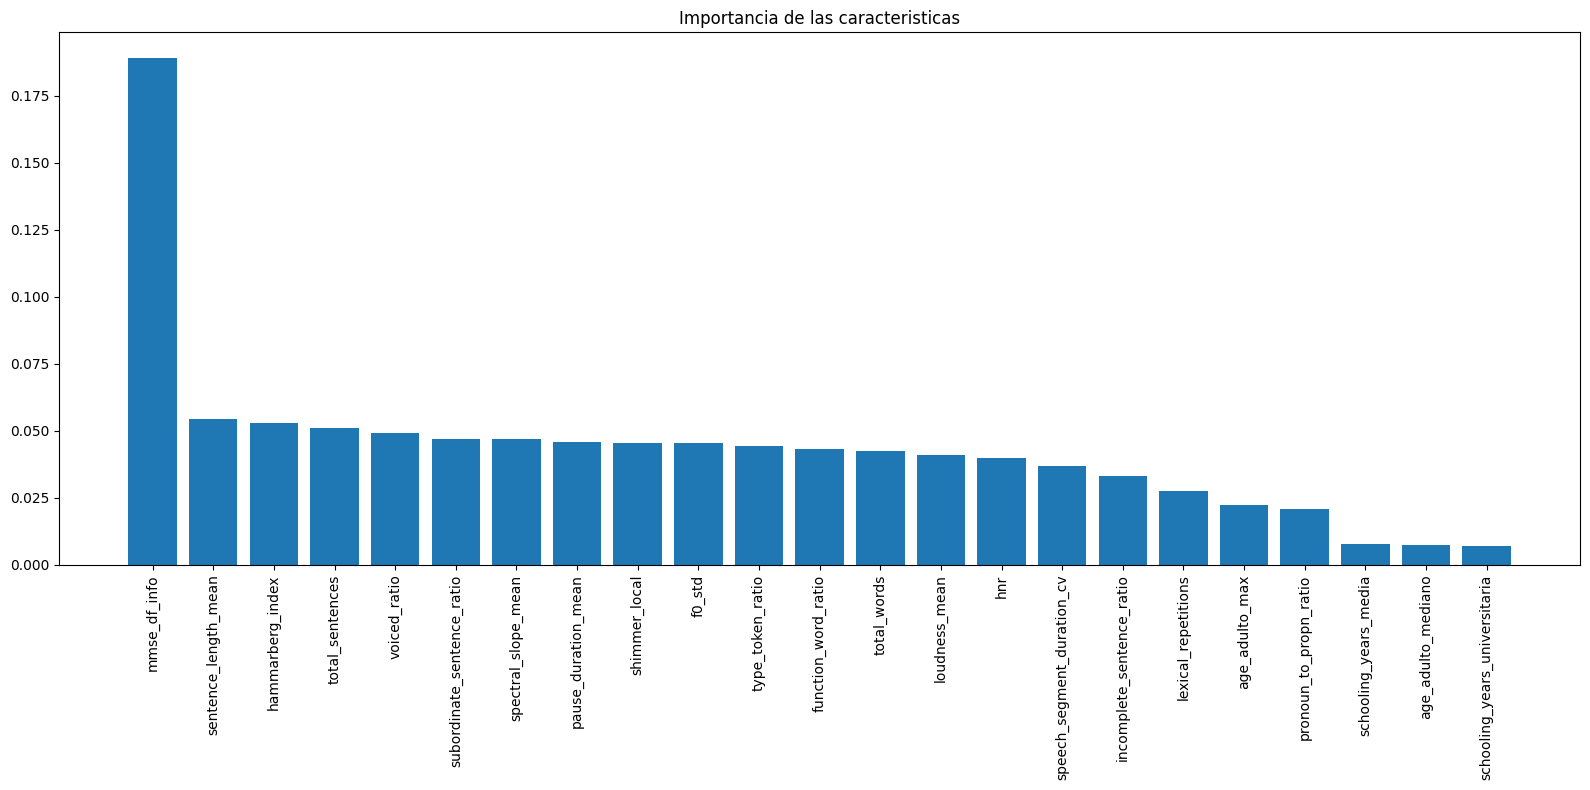

In [75]:
# obtener el mejor modelo del RandomizedSearchCV
best_rf = model_grid_rf.best_estimator_

# obtener importances
importances = best_rf.feature_importances_
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns
else:
    feature_names = [f"Feature {i}" for i in range(len(importances))]

#ordenar
indices = np.argsort(importances)[::-1]

# Graficar

plt.figure(figsize=(16,8))
plt.title("Importancia de las caracteristicas")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=90)
plt.tight_layout()
plt.show()

### Matrix de confusion

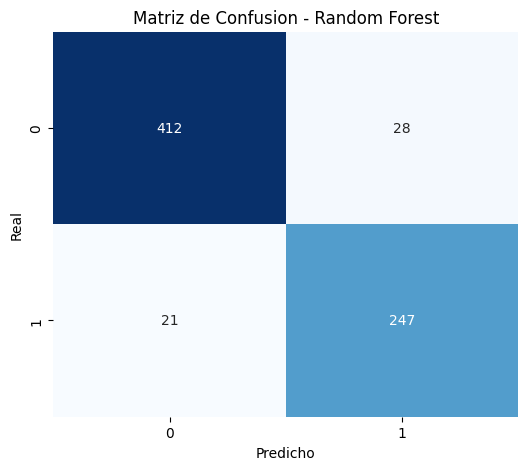

In [76]:
# predecir clases
y_pred_rf = model_grid_rf.predict(X_test)

# calcular la matriz de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Graficar
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusion - Random Forest')
plt.show()

### Un arbol del Random Forest

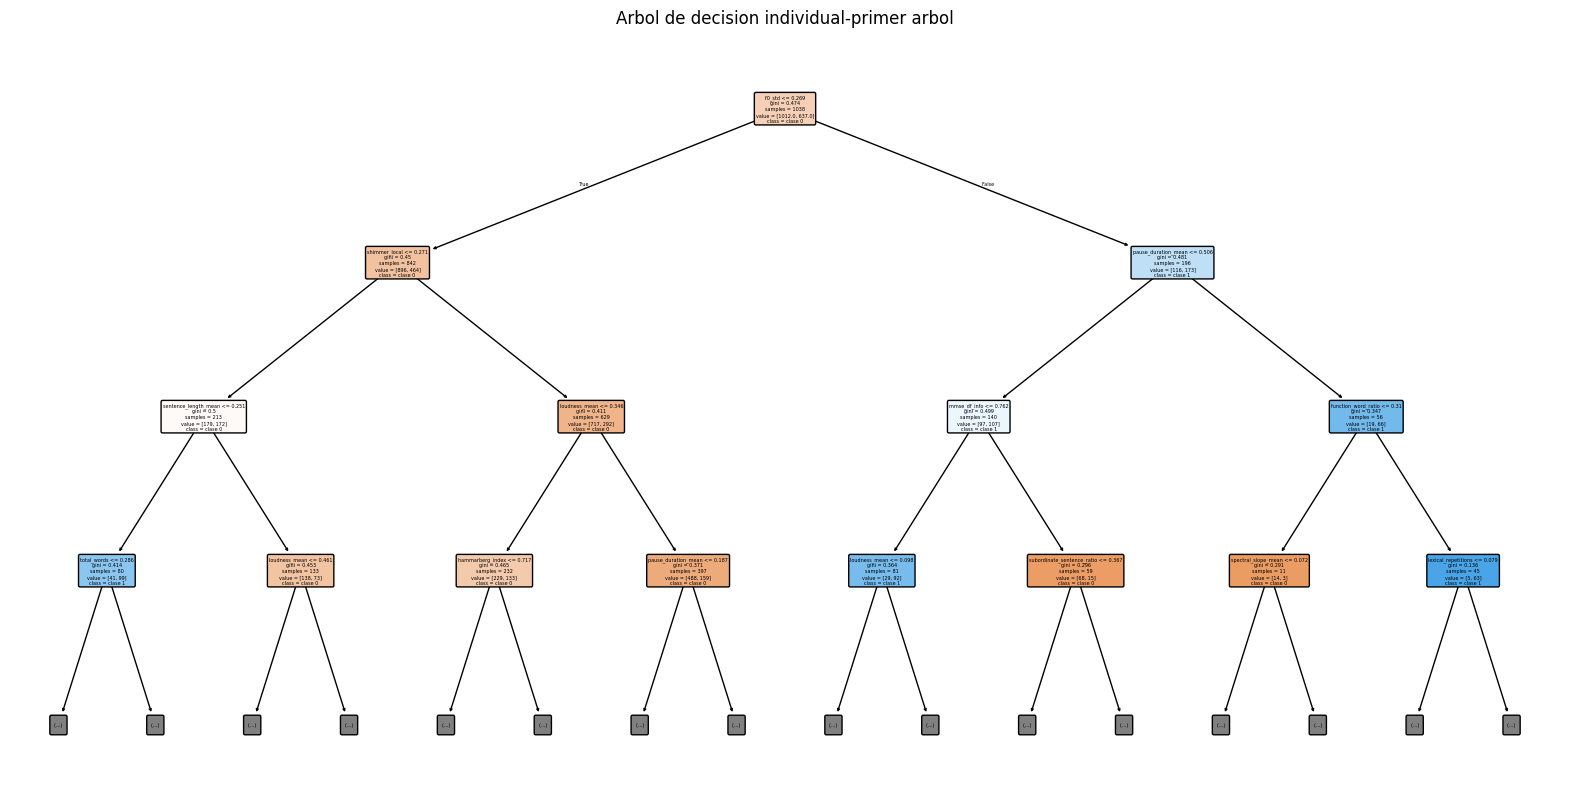

In [77]:
# seleccionar el primer arbol del bosque
tree_individual = best_rf.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(tree_individual,
          feature_names = feature_names,
          class_names=['clase 0', 'clase 1'],
          filled=True,
          rounded=True,
          max_depth=3)
plt.title('Arbol de decision individual-primer arbol')
plt.show()

## 